# Testing resolution/frame-overlap when one of the double disc choppers are slowed down

# McStas Results from Mo

## 6.68 meV (3.5 Å)

| Mode | Configuration | Resolution | Percetage
|---|---|---|---|
| HR | 24 RRM | 166 µeV | 2.485%
| HF | 24 RRM | 220 µeV | 3.29%
| HR | 22 RRM (M1 slowed) | 198 µeV | 2.96% 
| HF | 22 RRM (M1 slowed) | 242 µeV | 3.62%
| HR | 22 RRM (P1 slowed) | 202 µeV | 3.024%
| HF | 22 RRM (P1 slowed) | 260 µeV | 3.89%

## 3.58 meV (4.78 Å)

| Mode | Configuration | Resolution |
|---|---|---|
| HR | 24 RRM | 68 µeV |
| HF | 24 RRM | 86 µeV |
| HR | 22 RRM (M1 slowed) | 74 µeV |
| HF | 22 RRM (M1 slowed) | 92 µeV |
| HR | 22 RRM (P1 slowed) | 78 µeV |
| HF | 22 RRM (P1 slowed) | 100 µeV |

## 2.27 meV (6 Å)

| Mode | Configuration | Resolution |
|---|---|---|
| HR | 24 RRM | 34 µeV |
| HF | 24 RRM | 44 µeV |
| HR | 22 RRM (M1 slowed) | 37 µeV |
| HF | 22 RRM (M1 slowed) | 48 µeV |
| HR | 22 RRM (P1 slowed) | 39 µeV |
| HF | 22 RRM (P1 slowed) | 52 µeV |

In [1]:
%matplotlib widget

import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 3.5 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 22
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 2)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm22 = trex.run()
sample = Sample(en={"uniform": (4, 6)})
res_inelastic_rrm22 = trex.run(sample)

# Inelastic

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_20869/257053644.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


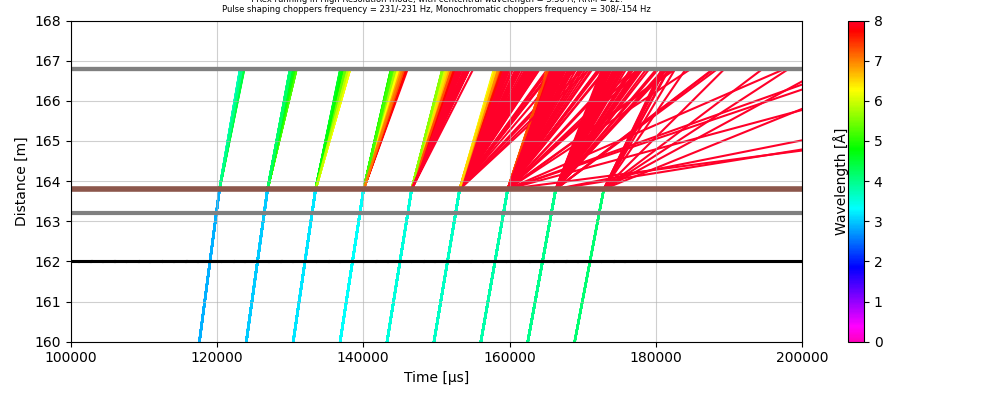

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm22.plot(ax=ax, vmin=0, vmax=8)
ax.set_xlim([100_000, 200_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

In [3]:
import plopp as pp

data = res_inelastic_rrm22.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 120_000, 200_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

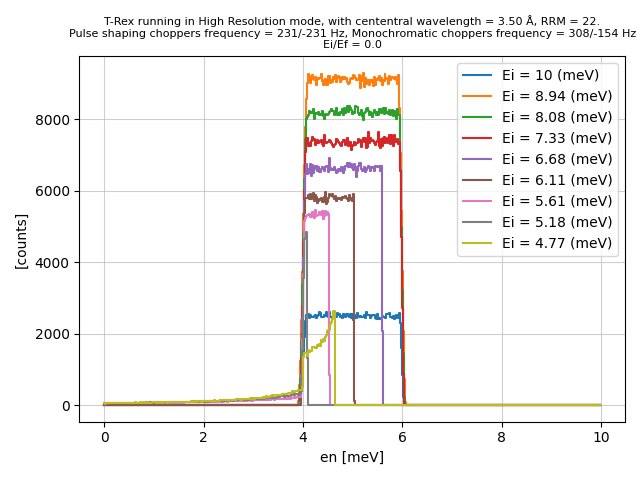

In [4]:
import plopp as pp

ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm22)
params = trex.unwrap_frame(res_elastic_rrm22, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm22, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", 0, 10, 0.02, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

# Elastic

In [5]:
trex.wrap_frame(res_elastic_rrm22)
params = trex.unwrap_frame(res_elastic_rrm22, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm22, *params)

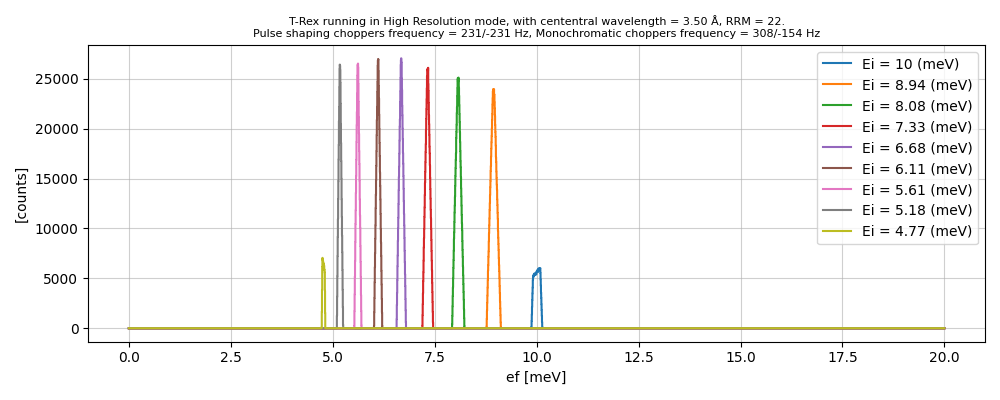

In [6]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 20, 0.005, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [7]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [10.0055, 8.9447, 8.0755, 7.3273, 6.6783, 6.1119, 5.6145, 5.1755, 4.7715] meV
delta en FWHM  = [0.1535, 0.169, 0.146, 0.1271, 0.1114, 0.0969, 0.0849, 0.0744, 0.0504] meV
delta en over ei = [0.015, 0.019, 0.018, 0.017, 0.017, 0.016, 0.015, 0.014, 0.011]
